In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import pandas as pd

# Use read_excel for .xlsx files
file_path = '/content/drive/MyDrive/data anylisis/vgsales.xlsx'

df = pd.read_excel(file_path)

# Display the first 5 rows to understand the structure
print("--- First 5 rows ---")
df.head()

--- First 5 rows ---


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [41]:
df = df.dropna(subset=['Year'])

# 2. Fill missing 'Publisher' values with "Unknown" to keep the sales data
df['Publisher'] = df['Publisher'].fillna('Unknown')
df = df[df['Year'] != 0]

print("--- Check Results ---")
print(df.isnull().sum())

df

--- Check Results ---
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [42]:
genre_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)
print(genre_sales)

Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
GB       254.42
XB       252.09
NES      251.07
3DS      246.28
N64      218.21
SNES     200.05
GC       197.14
XOne     141.06
2600      86.57
WiiU      81.86
PSV       61.63
SAT       33.59
GEN       28.36
DC        15.97
SCD        1.87
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: Global_Sales, dtype: float64


In [43]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
print(genre_sales)

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64


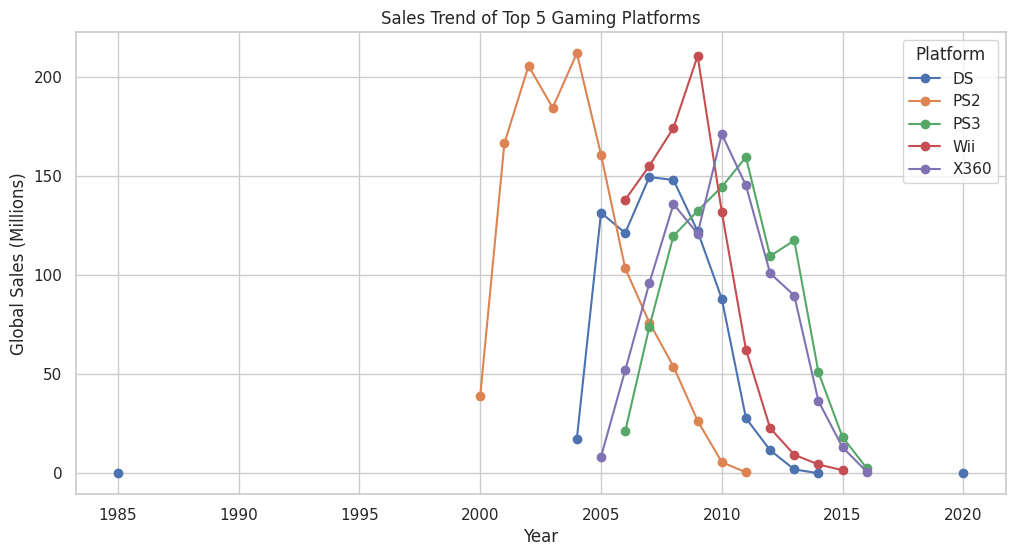

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

top_platforms = df.groupby('Platform')['Global_Sales'].sum().nlargest(5).index

df_top = df[df['Platform'].isin(top_platforms)]

top_lifecycle = df_top.groupby(['Year', 'Platform'])['Global_Sales'].sum().unstack()

top_lifecycle.plot(kind='line', figsize=(12, 6), marker='o')

plt.title('Sales Trend of Top 5 Gaming Platforms')
plt.ylabel('Global Sales (Millions)')
plt.grid(True)
plt.show()

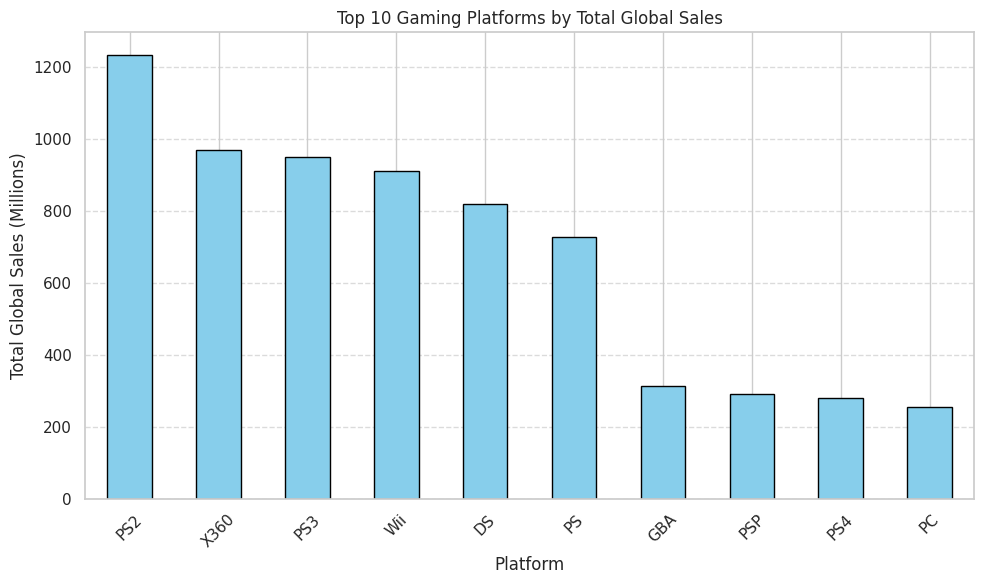

In [45]:
import matplotlib.pyplot as plt

platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)

top_10 = platform_sales.nlargest(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Top 10 Gaming Platforms by Total Global Sales')
plt.ylabel('Total Global Sales (Millions)')
plt.xlabel('Platform')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

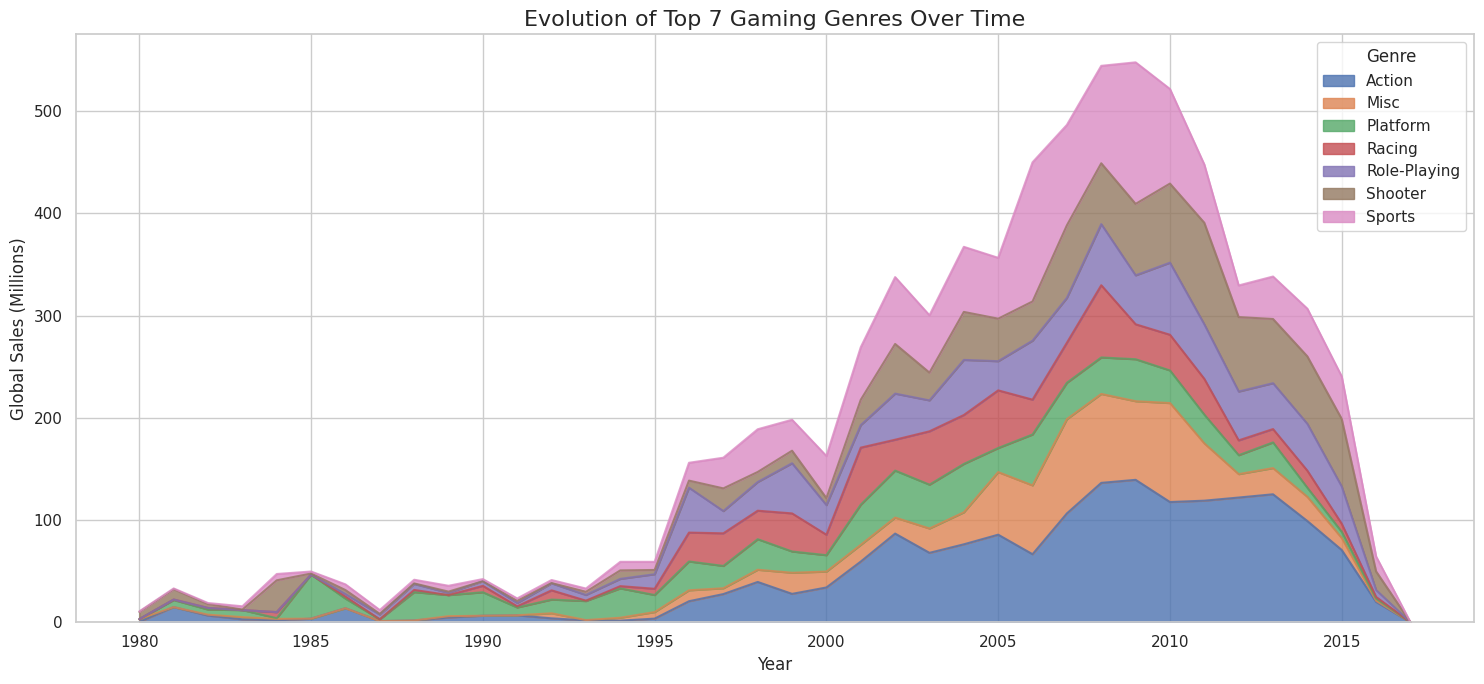

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

top_genres = df.groupby('Genre')['Global_Sales'].sum().nlargest(7).index

df_top_genres = df[df['Genre'].isin(top_genres)]

genre_evolution = df_top_genres.pivot_table(index='Year', columns='Genre', values='Global_Sales', aggfunc='sum').fillna(0)

plt.figure(figsize=(15, 7))
genre_evolution.plot(kind='area', figsize=(15, 7), stacked=True, alpha=0.8, ax=plt.gca())

plt.title('Evolution of Top 7 Gaming Genres Over Time', fontsize=16)
plt.ylabel('Global Sales (Millions)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Genre')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2693/4062821790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genres.index, y=top_10_genres.values, palette='viridis')


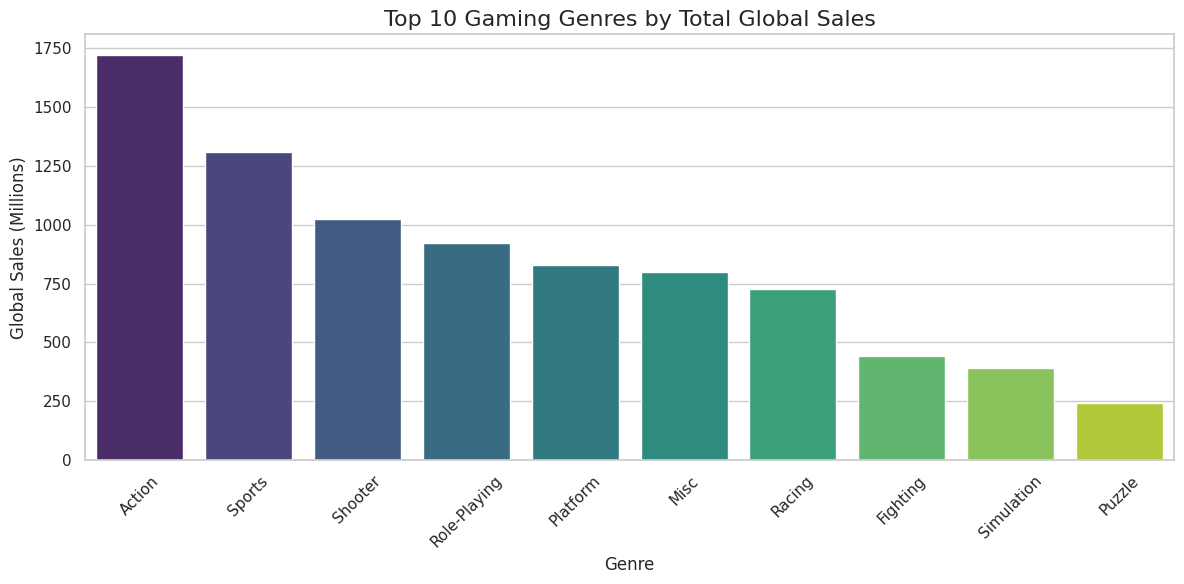

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_10_genres = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(10)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_genres.index, y=top_10_genres.values, palette='viridis')

plt.title('Top 10 Gaming Genres by Total Global Sales', fontsize=16)
plt.ylabel('Global Sales (Millions)', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

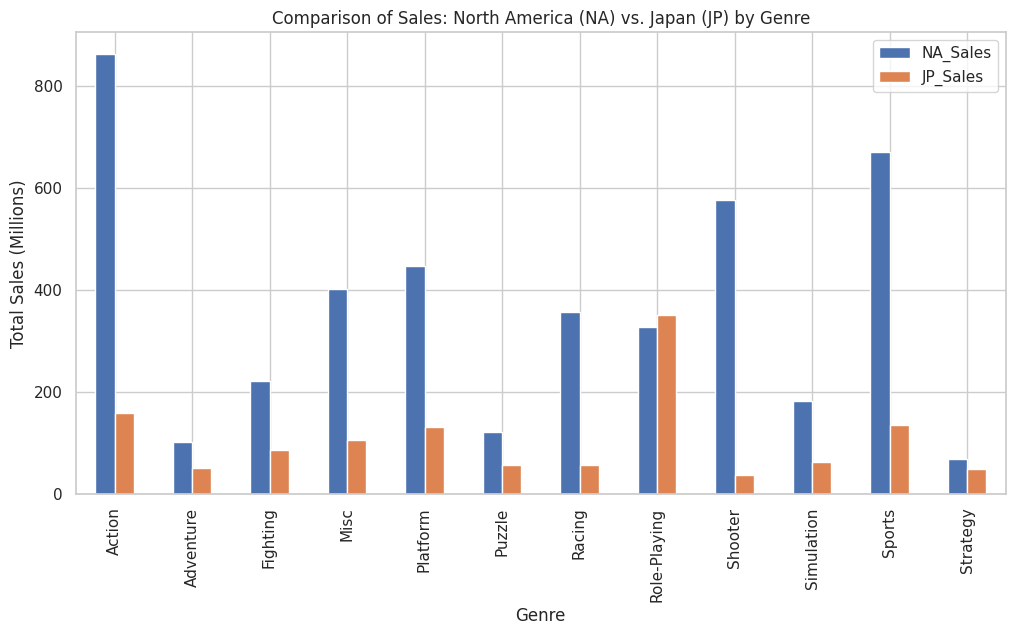

In [48]:
regional_comparison = df.groupby('Genre')[['NA_Sales', 'JP_Sales']].sum()

regional_comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of Sales: North America (NA) vs. Japan (JP) by Genre')
plt.ylabel('Total Sales (Millions)')
plt.show()

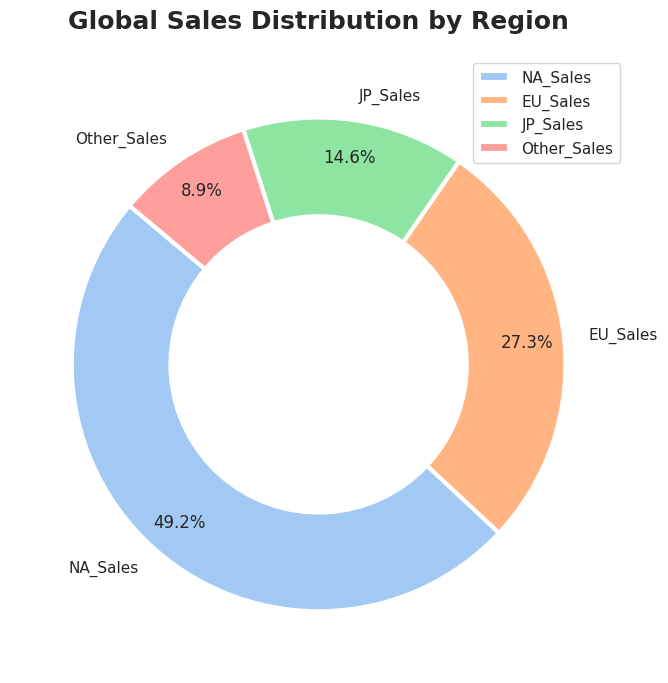

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

region_totals = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

colors = sns.color_palette('pastel')[0:4]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.pie(region_totals, labels=region_totals.index, autopct='%1.1f%%',
        startangle=140, pctdistance=0.85, colors=colors,
        wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 3})

centre_circle = plt.Circle((0,0), 0.60, fc='none', ec='none')
fig.gca().add_artist(centre_circle)

plt.title('Global Sales Distribution by Region', fontsize=18, fontweight='bold', pad=20)
plt.legend(region_totals.index)

plt.savefig('my_donut_chart.png', transparent=True, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

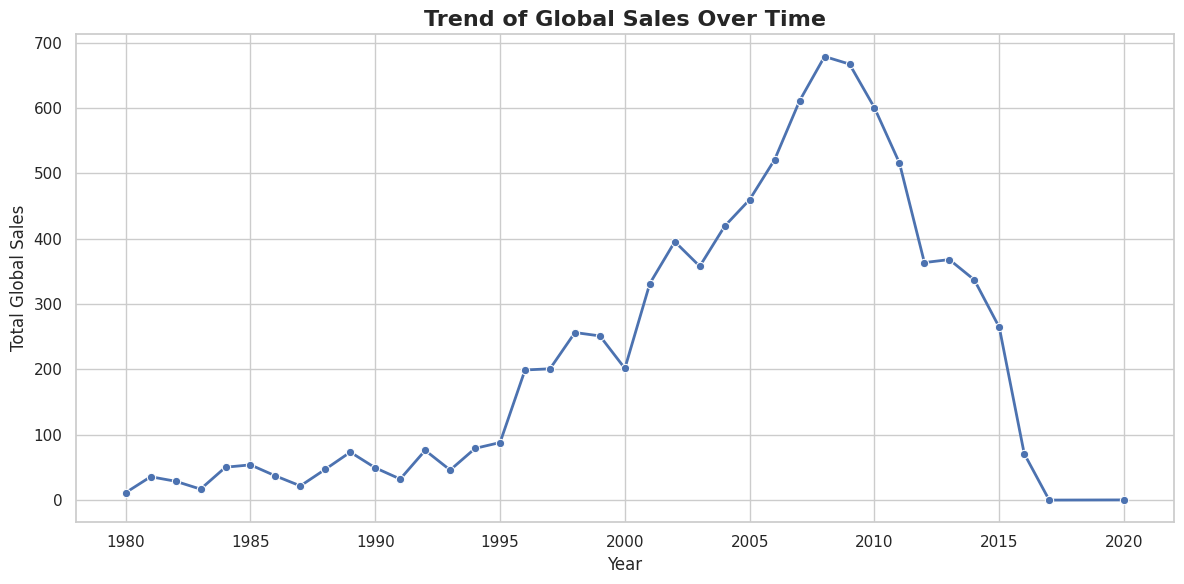

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

yearly_sales = df.groupby('Year')['Global_Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=yearly_sales, x='Year', y='Global_Sales', marker='o', color='b', linewidth=2)

plt.title('Trend of Global Sales Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Global Sales', fontsize=12)

plt.tight_layout()
plt.show()

In [51]:
# Calculate statistics for Global_Sales
mean_val = df['Global_Sales'].mean()
median_val = df['Global_Sales'].median()
mode_val = df['Global_Sales'].mode()[0] # Mode can have multiple values, so we take [0]
var_val = df['Global_Sales'].var()

# Display the results
print(f"Mean: {mean_val}")
print(f"Median: {median_val}")
print(f"Mode: {mode_val}")
print(f"Variance: {var_val}")

Mean: 0.5402315183438476
Median: 0.17
Mode: 0.02
Variance: 2.4515163496788195


In [52]:
from scipy import stats

# Drop rows with missing values (NaN) to ensure accurate calculation
na_sales = df['NA_Sales'].dropna()
jp_sales = df['JP_Sales'].dropna()

# Perform the Independent T-Test
# equal_var=False performs Welch's T-test, which is safer for unequal sample sizes
t_stat, p_value = stats.ttest_ind(na_sales, jp_sales, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpret the result based on the standard significance level (alpha = 0.05)
if p_value < 0.05:
    print("Result: The difference is statistically significant!")
else:
    print("Result: The difference is not statistically significant.")

T-statistic: 27.1576255701167
P-value: 1.198399385893761e-159
Result: The difference is statistically significant!


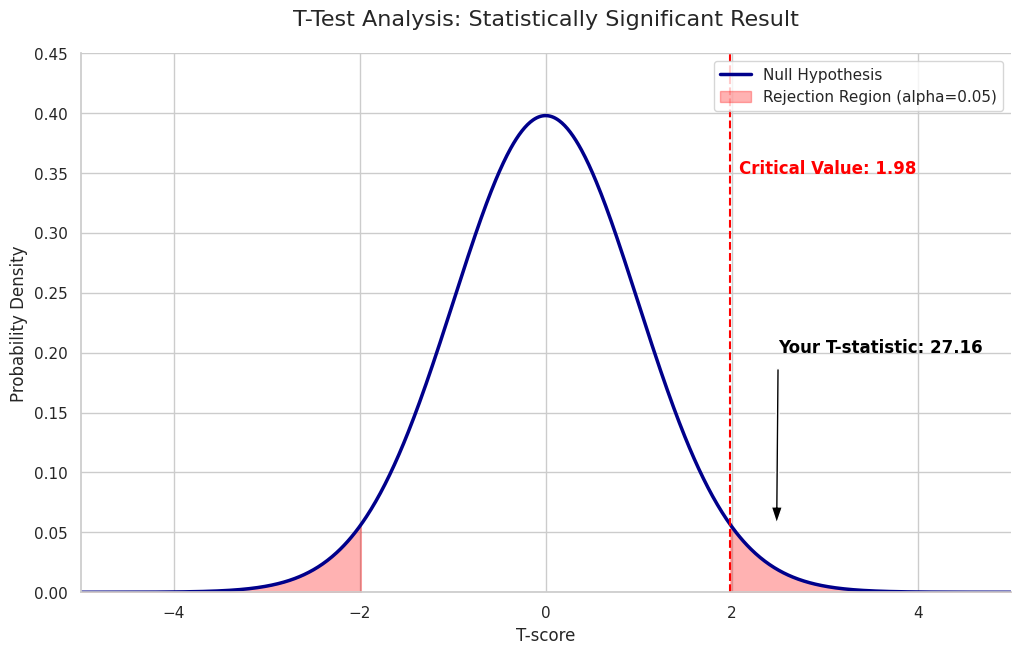

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

t_stat = 27.1576
alpha = 0.05
df = 100
crit_val = stats.t.ppf(1 - (alpha / 2), df)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

x = np.linspace(-5, 5, 1000)
y = stats.t.pdf(x, df)
sns.lineplot(x=x, y=y, color='darkblue', linewidth=2.5, label='Null Hypothesis')

plt.fill_between(x, y, where=(x >= crit_val), color='red', alpha=0.3, label='Rejection Region (alpha=0.05)')
plt.fill_between(x, y, where=(x <= -crit_val), color='red', alpha=0.3)

plt.axvline(crit_val, color='red', linestyle='--', linewidth=1.5)
plt.text(crit_val + 0.1, 0.35, f'Critical Value: {crit_val:.2f}', color='red', fontweight='bold')

plt.annotate(f'Your T-statistic: {t_stat:.2f}',
             xy=(crit_val + 0.5, 0.05),
             xytext=(2.5, 0.20),
             arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
             fontsize=12, fontweight='bold', color='black')

plt.title('T-Test Analysis: Statistically Significant Result', fontsize=16, pad=20)
plt.xlabel('T-score', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(loc='upper right')
plt.xlim(-5, 5)
plt.ylim(0, 0.45)

sns.despine()
plt.show()

In [ ]:
yearly_sales = df.groupby('Year')['Global_Sales'].sum()
print("\n--- Yearly Global Sales ---")
print(yearly_sales.tail(10))

genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
print("\n--- Sales by Genre ---")
print(genre_sales)

regional_comparison = df.groupby('Genre')[['NA_Sales', 'JP_Sales']].sum()
print("\n--- NA vs JP Sales by Genre ---")
print(regional_comparison)